# Physics-Informed Neural Networks (PINNs) para Equação da Difusão

## Introdução

As **Physics-Informed Neural Networks (PINNs)** são uma abordagem inovadora que combina redes neurais profundas com conhecimento físico para resolver equações diferenciais parciais (EDPs). Este notebook demonstra como implementar uma PINN para resolver a **equação da difusão unidimensional**.

### O Problema Físico

Vamos resolver a equação da difusão (também conhecida como equação do calor) em 1D:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

Onde:
- $u(t,x)$ é a temperatura no tempo $t$ e posição $x$
- $\alpha$ é o coeficiente de difusividade térmica
- Domínio: $t \in [0,1]$ e $x \in [-1,1]$

### Condições de Contorno e Inicial

1. **Condição inicial**: $u(0,x) = \sin(\pi x)$ - distribuição inicial de temperatura
2. **Condições de contorno**: $u(t,-1) = 0$ e $u(t,1) = 0$ - extremidades da barra mantidas a temperatura zero

### Solução Analítica

Para este problema específico, a solução analítica é conhecida:
$$u(t,x) = e^{-\alpha \pi^2 t} \sin(\pi x)$$

Isso nos permite comparar a precisão da nossa PINN!

In [1]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

## Passo 1: Importação das Bibliotecas

Começamos importando as bibliotecas essenciais:
- **PyTorch**: Framework principal para deep learning
- **NumPy**: Operações matemáticas e arrays
- **Matplotlib**: Visualização dos resultados
- **Time**: Medição do tempo de treinamento

In [3]:

# Define o dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando o dispositivo: {device}")

# Parâmetros da simulação
ALPHA = 0.1 # Coeficiente de difusividade
PI = np.pi

Usando o dispositivo: cpu


## Passo 2: Configuração do Dispositivo e Parâmetros

Aqui configuramos:
1. **Dispositivo**: Usa GPU (CUDA) se disponível, senão CPU
2. **Parâmetros físicos**:
   - `ALPHA = 0.1`: Coeficiente de difusividade térmica
   - `PI`: Constante matemática π

O dispositivo determina onde os cálculos serão executados. GPUs aceleram significativamente o treinamento de redes neurais.

In [5]:
# Célula 2: A Arquitetura da PINN (usando nn.Module)
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Rede MLP: 2 entradas (t, x) -> camadas ocultas -> 1 saída (u)
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, t, x):
        # Concatena as entradas t e x
        inputs = torch.cat([t, x], dim=1)
        return self.net(inputs)

# Instancia o modelo
pinn = PINN().to(device)

## Passo 3: Arquitetura da PINN

### Estrutura da Rede Neural

A PINN é uma rede neural feedforward (MLP - Multi-Layer Perceptron) com:

**Entrada**: 2 neurônios
- $t$: tempo
- $x$: posição espacial

**Camadas ocultas**: 3 camadas de 40 neurônios cada
- Função de ativação: $\tanh$ (tangente hiperbólica)
- A $\tanh$ é escolhida porque suas derivadas são suaves e bem comportadas

**Saída**: 1 neurônio
- $u(t,x)$: temperatura prevista

### Por que essa arquitetura?

1. **Profundidade suficiente**: 3 camadas permitem capturar relações complexas
2. **Largura adequada**: 40 neurônios por camada balanceiam capacidade e eficiência
3. **Função tanh**: Produz gradientes estáveis para o cálculo de derivadas automáticas

In [6]:
# Célula 3: Função de Perda e Resíduo da EDP

def pde_residual(model, t, x):
    """ Calcula o resíduo da equação da difusão. """
    t.requires_grad_(True)
    x.requires_grad_(True)

    u = model(t, x)

    # Calcula a primeira derivada de u em relação a t e x
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    # Calcula a segunda derivada de u em relação a x
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    # Retorna o resíduo da EDP
    return u_t - ALPHA * u_xx

# Otimizador
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)
loss_fn = nn.MSELoss() # Usaremos o Erro Quadrático Médio para todas as perdas

## Passo 4: Implementação da Física - Função de Perda PDE

### O Coração das PINNs: Diferenciação Automática

Esta é a parte mais importante! Aqui implementamos a **física** dentro da rede neural.

### Como funciona o `pde_residual`:

1. **Entrada**: O modelo, coordenadas temporais $t$ e espaciais $x$
2. **Habilitação de gradientes**: `requires_grad_(True)` permite calcular derivadas
3. **Previsão**: $u = \text{model}(t,x)$ - a rede prevê a temperatura
4. **Derivadas automáticas**:
   - $\frac{\partial u}{\partial t}$: derivada temporal (como a temperatura muda no tempo)
   - $\frac{\partial u}{\partial x}$: primeira derivada espacial
   - $\frac{\partial^2 u}{\partial x^2}$: segunda derivada espacial (curvatura)

5. **Resíduo da EDP**: 
   $$\text{resíduo} = \frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2}$$
   
   Se a rede estiver correta, este resíduo deve ser ≈ 0 em todos os pontos!

### Configuração do Otimizador

- **Adam**: Otimizador adaptativo eficiente
- **Learning rate**: 1e-3 (0.001) - taxa de aprendizagem moderada
- **MSE Loss**: Erro quadrático médio para todas as perdas

In [7]:
# Célula 4: Loop de Treinamento da PINN

# Pontos de treinamento
t_boundary = torch.tensor(0.0).view(-1, 1).to(device)
x_boundary = torch.linspace(-1, 1, 100).view(-1, 1).to(device)

t_collocation = torch.rand(1000, 1).to(device) * 1.0 # t entre 0 e 1
x_collocation = torch.rand(1000, 1).to(device) * 2 - 1 # x entre -1 e 1

iterations = 10000
start_time = time.time()

print("Iniciando treinamento da PINN...")
for i in range(iterations):
    optimizer.zero_grad()

    # 1. Perda da Condição Inicial (IC): u(0, x) = sin(pi*x)
    u_initial_pred = pinn(t_boundary.expand_as(x_boundary), x_boundary)
    u_initial_true = torch.sin(PI * x_boundary)
    loss_ic = loss_fn(u_initial_pred, u_initial_true)

    # 2. Perda das Condições de Contorno (BC): u(t, -1) = 0 e u(t, 1) = 0
    t_bc = torch.rand(100, 1).to(device)
    x_bc_left = torch.full_like(t_bc, -1)
    x_bc_right = torch.full_like(t_bc, 1)

    u_bc_left_pred = pinn(t_bc, x_bc_left)
    u_bc_right_pred = pinn(t_bc, x_bc_right)

    loss_bc = loss_fn(u_bc_left_pred, torch.zeros_like(u_bc_left_pred)) + \
              loss_fn(u_bc_right_pred, torch.zeros_like(u_bc_right_pred))

    # 3. Perda da Física (EDP): f = 0
    residual = pde_residual(pinn, t_collocation, x_collocation)
    loss_pde = loss_fn(residual, torch.zeros_like(residual))

    # Soma ponderada das perdas
    loss = loss_ic + loss_bc + loss_pde

    loss.backward()
    optimizer.step()

    if (i + 1) % 1000 == 0:
        print(f"Iteração {i+1}/{iterations}, Perda: {loss.item():.6f}")

training_time = time.time() - start_time
print(f"Treinamento concluído em {training_time:.2f} segundos.")

Iniciando treinamento da PINN...
Iteração 1000/10000, Perda: 0.000565
Iteração 2000/10000, Perda: 0.000394
Iteração 3000/10000, Perda: 0.000198
Iteração 4000/10000, Perda: 0.000088
Iteração 5000/10000, Perda: 0.000236
Iteração 6000/10000, Perda: 0.000074
Iteração 7000/10000, Perda: 0.000024
Iteração 8000/10000, Perda: 0.000088
Iteração 9000/10000, Perda: 0.000107
Iteração 10000/10000, Perda: 0.000024
Treinamento concluído em 233.64 segundos.


## Passo 5: Loop de Treinamento - A Magia das PINNs

### Três Tipos de Perda Combinadas

O treinamento da PINN é único porque combinamos **três tipos de conhecimento**:

#### 1. **Perda da Condição Inicial (IC Loss)**
- **O que**: Garante que $u(0,x) = \sin(\pi x)$
- **Como**: Avalia a rede em $t=0$ para diferentes posições $x$
- **Física**: Distribução inicial de temperatura na barra

#### 2. **Perda das Condições de Contorno (BC Loss)**  
- **O que**: Garante que $u(t,-1) = 0$ e $u(t,1) = 0$
- **Como**: Avalia a rede nos extremos da barra em tempos aleatórios
- **Física**: Extremidades da barra mantidas a temperatura zero

#### 3. **Perda da Física (PDE Loss)**
- **O que**: Garante que a EDP da difusão seja satisfeita
- **Como**: Usa o resíduo calculado em pontos aleatórios (collocation points)
- **Física**: Lei fundamental da difusão térmica

### Estratégia de Amostragem

- **Pontos de colocação**: 1000 pontos $(t,x)$ aleatórios no domínio
- **Condições de contorno**: 100 pontos aleatórios nos extremos
- **Por que aleatório?**: Evita overfitting a padrões regulares

### Processo de Otimização

1. **Forward pass**: Calcula previsões e resíduos
2. **Calcula perdas**: IC + BC + PDE
3. **Backpropagation**: Calcula gradientes
4. **Update**: Ajusta pesos da rede
5. **Repete**: Por 10.000 iterações

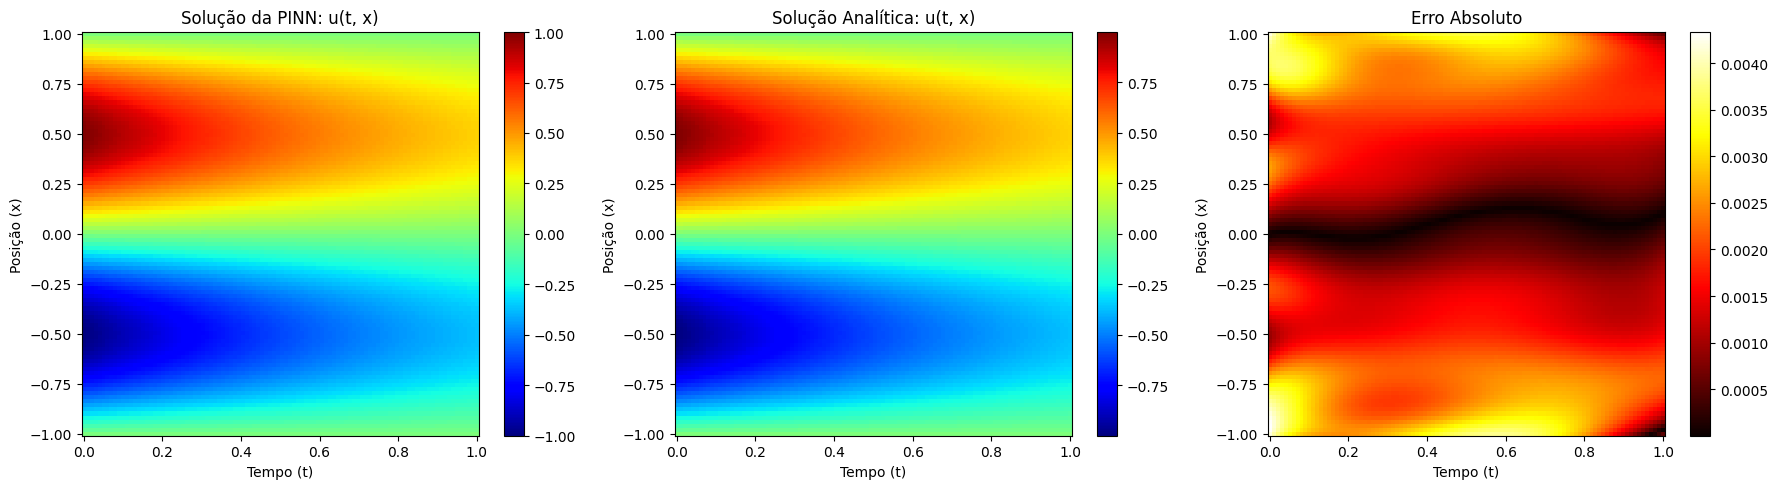

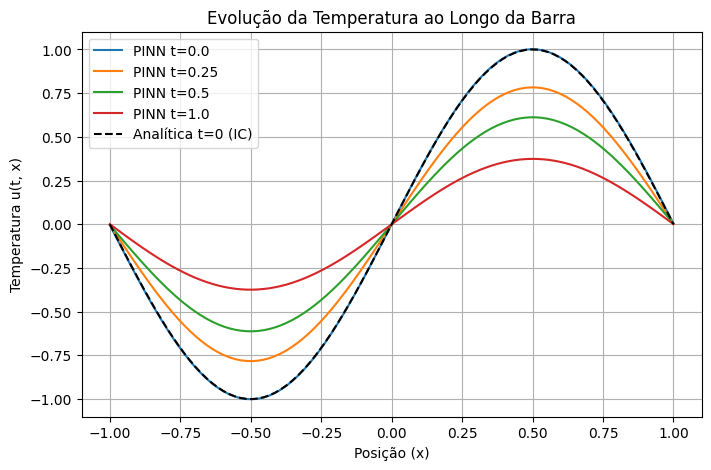

In [8]:
# Célula 5: Visualização e Comparação com a Solução Analítica

pinn.eval() # Coloca o modelo em modo de avaliação

# Cria uma grade de pontos para plotagem
t_plot = torch.linspace(0, 1, 100).to(device)
x_plot = torch.linspace(-1, 1, 100).to(device)
T, X = torch.meshgrid(t_plot, x_plot, indexing='ij')
T_flat = T.flatten().view(-1, 1)
X_flat = X.flatten().view(-1, 1)

# Previsões da PINN na grade
with torch.no_grad():
    U_pinn = pinn(T_flat, X_flat).view(100, 100).cpu().numpy()

# Solução analítica na grade
U_analytical = np.exp(-ALPHA * PI**2 * T.cpu().numpy()) * np.sin(PI * X.cpu().numpy())

# Erro absoluto
Error = np.abs(U_pinn - U_analytical)

# Plotagem dos resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot da Solução da PINN
c1 = axes[0].pcolormesh(T.cpu(), X.cpu(), U_pinn, cmap='jet')
fig.colorbar(c1, ax=axes[0])
axes[0].set_title('Solução da PINN: u(t, x)')
axes[0].set_xlabel('Tempo (t)')
axes[0].set_ylabel('Posição (x)')

# Plot da Solução Analítica
c2 = axes[1].pcolormesh(T.cpu(), X.cpu(), U_analytical, cmap='jet')
fig.colorbar(c2, ax=axes[1])
axes[1].set_title('Solução Analítica: u(t, x)')
axes[1].set_xlabel('Tempo (t)')
axes[1].set_ylabel('Posição (x)')

# Plot do Erro Absoluto
c3 = axes[2].pcolormesh(T.cpu(), X.cpu(), Error, cmap='hot')
fig.colorbar(c3, ax=axes[2])
axes[2].set_title('Erro Absoluto')
axes[2].set_xlabel('Tempo (t)')
axes[2].set_ylabel('Posição (x)')

plt.tight_layout()
plt.show()

# Plot de snapshots em diferentes tempos
fig, ax = plt.subplots(figsize=(8, 5))
times_to_plot = [0.0, 0.25, 0.5, 1.0]
for t_val in times_to_plot:
    t_tensor = torch.full_like(x_plot, t_val)
    with torch.no_grad():
        u_pred = pinn(t_tensor.view(-1, 1), x_plot.view(-1, 1)).cpu().numpy()
    ax.plot(x_plot.cpu().numpy(), u_pred, label=f'PINN t={t_val}')

# Adiciona a solução analítica para t=0 para comparação
ax.plot(x_plot.cpu().numpy(), np.sin(PI * x_plot.cpu().numpy()), 'k--', label='Analítica t=0 (IC)')
ax.set_title('Evolução da Temperatura ao Longo da Barra')
ax.set_xlabel('Posição (x)')
ax.set_ylabel('Temperatura u(t, x)')
ax.legend()
ax.grid(True)
plt.show()

## Resumo e Conclusões

### O que Aprendemos sobre PINNs

**Physics-Informed Neural Networks** representam um paradigma revolucionário que combina:

1. **Capacidade de Aproximação** das redes neurais profundas
2. **Conhecimento Físico** através de equações diferenciais
3. **Diferenciação Automática** para calcular derivadas exatas

### Vantagens das PINNs:

- ✅ **Sem necessidade de dados**: Resolve EDPs sem dados experimentais massivos
- ✅ **Incorpora física**: Garante que as leis físicas sejam respeitadas
- ✅ **Meshfree**: Não precisa de discretização espacial prévia
- ✅ **Interpolação**: Fornece solução contínua em todo o domínio

### Limitações e Desafios:

- ❌ **Convergência**: Pode ser sensível a hiperparâmetros
- ❌ **Balanceamento**: Equilibrar diferentes termos de perda é crucial  
- ❌ **Complexidade**: EDPs mais complexas requerem arquiteturas sofisticadas
- ❌ **Computação**: Cálculo de derivadas aumenta custo computacional

### Aplicações Práticas:

- 🌡️ **Transferência de calor** (como neste exemplo)
- 🌊 **Dinâmica de fluidos** (Navier-Stokes)
- ⚡ **Eletromagnetismo** (Equações de Maxwell)
- 🏗️ **Mecânica estrutural** (Elasticidade)
- 💰 **Finanças quantitativas** (Black-Scholes)

### Próximos Passos:

1. Experimente diferentes arquiteturas de rede
2. Teste outras EDPs (Burgers, Wave equation, etc.)
3. Implemente PINNs para problemas 2D/3D
4. Explore técnicas de balanceamento de perdas
5. Investigue PINNs para problemas inversos

## Passo 6: Visualização e Validação dos Resultados

### Avaliação Completa da Solução

Após o treinamento, avaliamos a qualidade da nossa PINN comparando com a solução analítica.

#### Processo de Avaliação:

1. **Modo de Avaliação**: `pinn.eval()` desativa dropout e batch normalization
2. **Grade de Avaliação**: 100×100 pontos cobrindo todo o domínio espaço-temporal
3. **Comparação Quantitativa**: Calcula erro absoluto ponto a ponto

#### Três Visualizações Principais:

**Gráfico 1 - Solução da PINN**
- Mostra $u(t,x)$ previsto pela rede neural
- Colormap representa intensidade da temperatura
- Eixos: tempo (horizontal) vs posição (vertical)

**Gráfico 2 - Solução Analítica**  
- Solução exata: $u(t,x) = e^{-\alpha \pi^2 t} \sin(\pi x)$
- Referência para avaliar precisão da PINN
- Deve ser visualmente similar ao Gráfico 1

**Gráfico 3 - Erro Absoluto**
- $|\text{PINN} - \text{Analítica}|$
- Idealmente deve ser próximo de zero (cor escura)
- Regiões mais claras indicam maior erro

#### Snapshots Temporais:
- Mostra evolução da temperatura em momentos específicos
- Permite visualizar como o calor se dissipa ao longo do tempo
- Compara perfis da PINN com a condição inicial analítica

### Interpretação Física:
- Temperatura inicial: distribuição senoidal $\sin(\pi x)$
- Com o tempo: a temperatura se dissipa (decay exponencial)
- Extremidades: sempre permanecem a zero (condições de contorno)